# Worksheet 4: watching a trained agent play

Your project: *teaching a neural network to play Atari Pong using nothing but the
screen.*

Worksheets 1–3 built up every piece: the environment, the network, and one learning step.
This one loads a policy that has already run that loop about a hundred thousand times, and
takes it apart.

Nothing here trains. The weights are frozen throughout: this is inference, and seeing the difference between
inference and training is half the point.

## 1. What you will learn

1. What a checkpoint actually contains, and which parts you need to play versus to resume
   training.
2. How 100,800 raw numbers become the 6400 the network sees, each stage, visually.
3. Why the network is fed the *difference* between frames, shown rather than asserted.
4. How one decision is made: probability, sample, log-prob, Atari action.
5. Why the same weights score differently depending on how you read their output, the
   exploration tax.
6. How to watch a full episode inside a notebook, with no ffmpeg and no window.

## Running this notebook

Locally: the environment comes from the repo. `uv sync --locked`, then
`uv run jupyter lab`. The cell below does nothing.

On Colab: the kernel exists before the project does, so the cell below clones the
repo and installs what Colab is missing. Run it first.

It installs `gymnasium` and `ale-py` only. Colab already provides a working CUDA build
of torch, and replacing it with the exact locked one means downloading the entire CUDA
stack for no benefit to anything taught here. The README describes the stricter route
if you ever need bit-identical versions.

The cell ends by importing `pong`, so if anything above failed you find out here rather
than three cells later.


In [1]:
# Colab bootstrap. Does nothing when you run this notebook locally.
import sys

IN_COLAB = "google.colab" in sys.modules
REPO = "/content/pong"
URL = "https://github.com/piyushahuja/pong.git"

if IN_COLAB:
    # Idempotent: clone if it is missing, refresh it if it is already there.
    # Safe to re-run, and fast on a runtime that has done it before.
    ![ -d {REPO} ] || git clone -q {URL} {REPO}
    !git -C {REPO} pull -q || true
    %cd {REPO}

    !command -v uv >/dev/null || curl -LsSf https://astral.sh/uv/install.sh | env UV_INSTALL_DIR=/usr/local/bin sh
    !uv pip install -q --system --python {sys.executable} gymnasium ale-py

    # Deliberately not an editable install: that works by dropping a .pth file
    # into site-packages, and .pth files are only read when the interpreter
    # starts, so it would not take effect in this already-running kernel.
    sys.path.insert(0, f"{REPO}/src")

import pong        # fails here, loudly, if any of the above did not work

print("python:", sys.version.split()[0])
print("pong package from:", pong.PROJECT_ROOT)


python: 3.12.14
pong package from: /Users/piyush/Code/ml/pong


In [2]:
# Confirm the environment is what you think it is.
import torch
import gymnasium
import ale_py

print("torch:     ", torch.__version__)
print("gymnasium: ", gymnasium.__version__)
print("ale-py:    ", ale_py.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))


torch:      2.14.0
gymnasium:  1.3.0
ale-py:     0.12.1
CUDA available: False


In [3]:
import torch
import matplotlib.pyplot as plt

import pong        # Policy, preprocess, make_env, rollout
from pong import replay        # watch, animate

print(torch.__version__)

2.14.0


## 2. What a checkpoint actually holds

`scripts/train.py` saves a dictionary, not a bare model. Four keys:

| Key | What it is | Needed to play? |
|---|---|---|
| `model_state_dict` | the learned weights | yes |
| `optimizer_state_dict` | RMSprop's running averages | no, only to *resume training* |
| `episode` | how many episodes produced it | no |
| `running_reward` | training-time score, smoothed | no |

A `state_dict` is just an ordered mapping from parameter name to tensor. It carries no
architecture, which is why you must construct the same `Policy` class before loading into it.

In [4]:
# pong.default_checkpoint() prefers a live pong_policy.pt from a local
# training run, and otherwise falls back to the newest archived policy in
# checkpoints/, which is what a fresh clone has.
path = pong.default_checkpoint()
print('checkpoint:', path)

ckpt = torch.load(path, map_location='cpu', weights_only=False)

print('keys:', list(ckpt))
print('trained for', ckpt['episode'], 'episodes')
print('training running reward:', round(ckpt['running_reward'], 2))
print()
for name, tensor in ckpt['model_state_dict'].items():
    print(f'{name:12s} {tuple(tensor.shape)}  {tensor.numel():,} parameters')

checkpoint: /Users/piyush/Code/ml/pong/pong_policy.pt
keys: ['episode', 'model_state_dict', 'optimizer_state_dict', 'running_reward']
trained for 109100 episodes
training running reward: 8.22

fc1.weight   (200, 6400)  1,280,000 parameters
fc2.weight   (1, 200)  200 parameters


Read the four keys against the table above, then look at the two weight shapes.

`fc1.weight` is `(200, 6400)` and `fc2.weight` is `(200,)`-wide going to 1, the 6400 → 200
→ 1 network from Worksheet 2, with no bias entries at all. That is deliberate: the
policy is two bare weight matrices.

The episode count tells you how much work is embodied in this file. At roughly two seconds
per episode on a CPU, a hundred thousand episodes is days of continuous computation, and all
of it is compressed into these two tensors.

`running_reward` is the score at the time of saving, and it was measured *while sampling*
mid-training, hold on to that, because section 7 shows it understates the policy.

That is the same two-layer shape as `PongShapedNet` in
[Notebook 2](02_neural_network.ipynb), $6400 \rightarrow 200 \rightarrow 1$, with one
difference: no biases, matching the original NumPy implementation.

$$
p = \sigma\!\left(W_2 \;\mathrm{relu}(W_1 x)\right), \qquad
W_1 \in \mathbb{R}^{200 \times 6400}, \quad W_2 \in \mathbb{R}^{1 \times 200}
$$

Two matrices. That is the entire agent.

In [5]:
policy = pong.load_policy()
policy.eval()

total = sum(p.numel() for p in policy.parameters())
print(policy)
print(f'\ntotal parameters: {total:,}')

loaded /Users/piyush/Code/ml/pong/pong_policy.pt | episode 109100 | running reward 8.22
Policy(
  (fc1): Linear(in_features=6400, out_features=200, bias=False)
  (fc2): Linear(in_features=200, out_features=1, bias=False)
)

total parameters: 1,280,200


1,280,200 parameters, and `policy.eval()` before anything else.

There is no dropout or batch-norm in this network, so `eval()` changes nothing numerically
here. It is still worth calling, because it states the intent, and because the moment
someone adds dropout, forgetting it turns every evaluation into a measurement of a randomly
damaged network.

Notice what loading required: constructing `Policy()` *first*, then pouring the weights in.
A `state_dict` carries no architecture. Get the shape wrong and the load fails, which is why
a checkpoint only means something next to the code that produced it.

## 3. From pixels to 6400 numbers

ALE hands you a `210 x 160 x 3` RGB frame. The policy wants a flat vector. `pong.preprocess`
does four things, in order:

| Step | Code | Shape after |
|---|---|---|
| Crop score bar and floor | `x[35:195]` | `160 x 160 x 3` |
| Downsample, keep one channel | `x[::2, ::2, 0]` | `80 x 80` |
| Background to 0, everything else to 1 | `(x != 144) & (x != 109) & (x != 0)` | `80 x 80` |
| Flatten | `x.flatten()` | `6400` |

Note what survives: two paddles and a ball, as ones on a field of zeros. Colour, score
digits and court markings are all discarded. The agent never sees them.

In [6]:
env = pong.make_env('rgb_array')
observation, _ = env.reset(seed=1)

# Step a little so the ball is actually in play.
for _ in range(22):
    observation, *_ = env.step(0)

print('raw frame from ALE:', observation.shape, observation.dtype)

raw frame from ALE: (210, 160, 3) uint8


A.L.E: Arcade Learning Environment (version 0.12.1+8a8fafb)
[Powered by Stella]


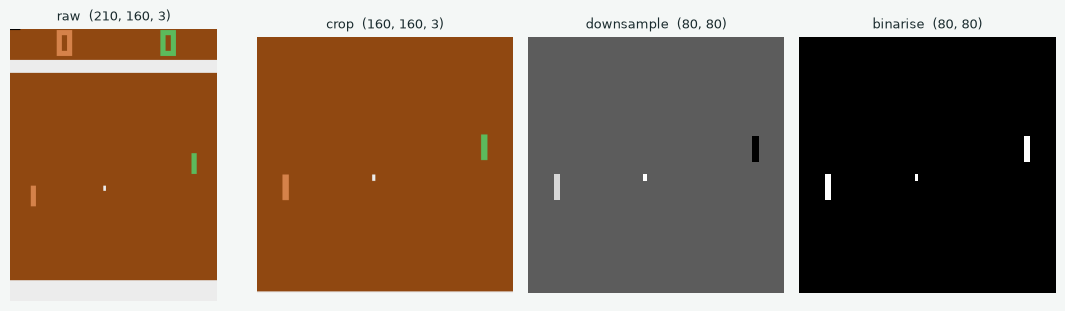

flattened: (6400,)
fraction of pixels that are 1: 0.0053


In [7]:
# The same four steps, kept separate so you can see each one.
raw       = torch.from_numpy(observation)
cropped   = raw[35:195]
downsized = cropped[::2, ::2, 0]
binary    = ((downsized != 144) & (downsized != 109) & (downsized != 0)).float()
flat      = binary.flatten()

stages = [
    (raw,       f'raw  {tuple(raw.shape)}'),
    (cropped,   f'crop  {tuple(cropped.shape)}'),
    (downsized, f'downsample  {tuple(downsized.shape)}'),
    (binary,    f'binarise  {tuple(binary.shape)}'),
]

fig, axes = plt.subplots(1, 4, figsize=(11, 3.2))
fig.patch.set_facecolor('#f4f7f6')
for ax, (img, label) in zip(axes, stages):
    ax.imshow(img.numpy(), cmap='gray' if img.ndim == 2 else None)
    ax.set_title(label, fontsize=9, color='#1a2b2e')
    ax.axis('off')
plt.tight_layout()
plt.show()

print('flattened:', tuple(flat.shape))
print('fraction of pixels that are 1:', round(flat.mean().item(), 4))

Look at the four panels in order, because this is where "100,800 numbers" becomes concrete.

Raw is the whole screen, scoreboard included. Crop removes rows outside 35:195, the score digits and the floor, which never affect play. Downsample takes every second
pixel in both directions and keeps one colour channel, so 160×160×3 becomes 80×80.
Binarise throws away colour entirely: background to 0, ball and paddles to 1.

Count what survived: 100,800 numbers became 6400, a reduction of about 94%. And nothing the
agent needs was lost, the ball and both paddles are still visible in the last panel. That
is the whole argument for preprocessing, in four pictures.

Each stage also encodes an assumption. Cropping assumes the scoreboard is irrelevant.
Binarising assumes colour is irrelevant. Both are true of Pong and would be wrong for a game
where they are not.

## 4. The network sees motion, not a still

A single binarised frame is ambiguous: it shows *where* the ball is, never *where it is going*.
A policy fed one frame cannot tell an approaching ball from a departing one.

The fix costs nothing. Feed the difference of consecutive frames:

$$
x_t = \text{prepro}(o_t) - \text{prepro}(o_{t-1})
$$

Now moving objects appear twice, $+1$ where they arrived, $-1$ where they left, and static
objects cancel to zero. Direction is encoded in the sign. On the very first step there is no
previous frame, so `scripts/train.py` passes a vector of zeros.

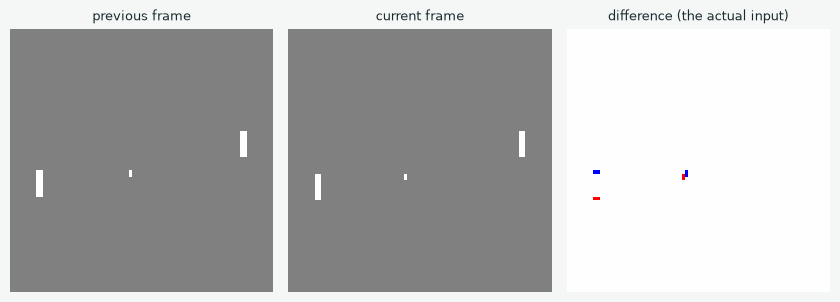

nonzero in a single frame : 34
nonzero in the difference : 8
value range               : -1.0 to 1.0


In [8]:
previous = pong.preprocess(observation)
observation, *_ = env.step(0)
current  = pong.preprocess(observation)

difference = current - previous

fig, axes = plt.subplots(1, 3, figsize=(8.5, 3.2))
fig.patch.set_facecolor('#f4f7f6')
for ax, (img, label, cmap) in zip(axes, [
    (previous,   'previous frame',  'gray'),
    (current,    'current frame',   'gray'),
    (difference, 'difference (the actual input)', 'bwr'),
]):
    ax.imshow(img.reshape(80, 80).numpy(), cmap=cmap, vmin=-1, vmax=1)
    ax.set_title(label, fontsize=9, color='#1a2b2e')
    ax.axis('off')
plt.tight_layout()
plt.show()

print('nonzero in a single frame :', int((current != 0).sum()))
print('nonzero in the difference :', int((difference != 0).sum()))
print('value range               :', difference.min().item(), 'to', difference.max().item())

The third panel is the one to study. It is what the network actually receives, and it looks
almost empty.

Compare the two nonzero counts printed underneath. A single frame has several hundred
nonzero pixels, paddles and ball. The difference has far fewer, because everything that
did not move cancelled to zero. The paddles mostly vanish; what is left is the handful of
pixels where the ball was and is.

That is the answer to "how does the agent know which way the ball is going?" A still frame
cannot say. Subtract consecutive frames and direction falls out of the arithmetic: the old
position is negative, the new one positive. In the `bwr` colour map, one is blue and the
other red.

Two frames, one subtraction, and velocity becomes visible without anyone computing a
velocity.

## 5. One decision

This is [Notebook 3](03_train_step.ipynb)'s Bernoulli section, with a real $p$ from real
pixels. The network emits one number; ALE wants an integer action code:

| Bernoulli sample | Atari action | Meaning |
|---|---|---|
| `1` | `2` | UP |
| `0` | `3` | DOWN |

Only two of Pong's actions are ever used. The agent cannot stay still, and does not need to.

In [9]:
with torch.no_grad():
    p = policy(difference)

dist = torch.distributions.Bernoulli(probs=p)
sample = dist.sample()

print(f'P(UP)          : {p.item():.4f}')
print(f'sampled        : {int(sample.item())}  -> Atari action {2 if sample.item() == 1 else 3}')
print(f'log_prob       : {dist.log_prob(sample).item():.4f}')
print(f'greedy (argmax): {2 if p.item() > 0.5 else 3}')

P(UP)          : 0.7678
sampled        : 0  -> Atari action 3
log_prob       : -1.4601
greedy (argmax): 2


This is one complete decision, and every number in it appeared in Worksheet 3, now with
real pixels behind it.

`P(UP)` is the network's single output. The sample is a Bernoulli draw from it. `log_prob`
scores that draw. And the Atari action is 2 or 3 depending on the sample.

Two differences from training. First, `torch.no_grad()`: we are not going to call
`backward()`, so there is no reason to build a graph, and saying so saves memory and time.
Second, the greedy read-out on the last line ignores the sample entirely and just asks
whether `P(UP)` is above a half.

During training that would be a mistake, a deterministic policy produces no variation for
`log_prob` to push on, so it generates no learning signal at all. At play time it is simply
better. That is the next section.

### See the whole thing at once

You have now followed one frame through one decision. The demo does it for a whole rally, with
every number computed in your browser from these same weights:

[Open the forward pass demo](https://piyushahuja.com/pong/demos/forward-pass.html)

The court is the difference image. The 200 bars are the hidden units firing. The two towers are
the committees adding up their votes for up and for down.

Watch for one thing in particular. Each hidden unit is sensitive to a path across the court,
drawn as a streak, and it is tempting to read that as a switch that fires when the ball is on
it. It is not. Measured over 2,050 frames, a unit fires 49 to 51 percent of the time at every
distance from its own streak. What changes is how hard: mean activation 0.42 on the streak
against 0.26 when the ball is 34 to 60 pixels away, about 1.6 times. A bias, not a switch.

The companion view, of what the units collectively look for, is
[trajectory committees](https://piyushahuja.com/pong/demos/trajectory-committees.html).

## 6. Greedy or sampling? The exploration tax

During training the agent must sample. Sampling is what produces the variation that
`log_prob` can then be pushed up or down, a deterministic policy generates no learning signal.

At play time that constraint is gone. You can take the argmax and keep the noise.

The `running_reward` printed above was measured while sampling, during training.
It therefore understates what the policy can do once it stops exploring. Compare the two
read-outs yourself:

In [10]:
results = []
print('playing 6 full episodes, this takes ~30s...')
for seed in range(3):
    for greedy in (True, False):
        us, them, _, _ = pong.rollout(policy, env, greedy=greedy, seed=seed, verbose=False)
        results.append((seed, 'argmax' if greedy else 'sample', us, them))

print(f"\n{'seed':>5}  {'mode':>7}  {'score':>7}  result")
for seed, mode, us, them in results:
    print(f'{seed:>5}  {mode:>7}  {us:>3} - {them:<3}  {"WIN" if us > them else "loss"}')

playing 6 full episodes, this takes ~30s...



 seed     mode    score  result
    0   argmax   21 - 5    WIN
    0   sample   21 - 9    WIN
    1   argmax   21 - 15   WIN
    1   sample   21 - 6    WIN
    2   argmax   21 - 9    WIN
    2   sample   21 - 15   WIN


Six games, same frozen weights, two ways of reading them, and the result is probably not
what you expected.

Every game was won, in both modes. The argmax margins here were 16, 6 and 12; the sampling
margins were 13, 5 and 15. On seed 2 sampling actually did better. There is no clear gap.

That is worth understanding rather than explaining away, because the gap is real in
principle. Sampling and argmax only disagree when the policy is unsure: if `P(UP)` is 0.97,
a Bernoulli draw agrees with the argmax 97% of the time, so the two behave almost
identically. Early in training, when probabilities sit near 0.5, they disagree constantly and
the difference is large. This policy has trained for around a hundred thousand episodes and
is confident on most frames, so it has already paid the tax down close to nothing.

Which leaves a sharper question, and it is the one Exercise 4.4 asks: with margins spread
from 5 to 16 *within* each mode, three seeds cannot tell you whether a mode difference
exists at all. The seed-to-seed spread is larger than any gap between the modes. Two numbers
that differ are not evidence until you know how much they bounce on their own.

The other thing this explains is the `running_reward` in the checkpoint: it was recorded
while sampling *and* while still learning, so it reflects a weaker, less confident version of
these same weights.


Same weights, two read-outs. The gap between them is the price the agent pays for exploring,
and it is refundable the moment learning stops.

## 7. Watch it play

`replay.watch` runs one episode with `render_mode='rgb_array'`, collects the frames, and returns
an HTML5 player. The bar on the right is the policy's own $P(\text{UP})$ at that frame, teal
above $0.5$, red below. Scrub it and watch the bar commit as the ball approaches.

Size warning. Each frame costs roughly 13 KB of embedded PNG. `max_steps=1500` gives five or
six points for about 4 MB. A full 21-point episode would bloat the notebook to ~17 MB, raise
`frame_stride` if you want the whole match.

In [11]:
replay.watch(seed=1, max_steps=1500, frame_stride=3)

loaded /Users/piyush/Code/ml/pong/pong_policy.pt | episode 109100 | running reward 8.22
  step   121  WE SCORE    1 - 0  !!!
  step   250  WE SCORE    2 - 0  !!!
  step   375  WE SCORE    3 - 0  !!!
  step   463  they score  3 - 1 
  step   756  they score  3 - 2 
  step   846  WE SCORE    4 - 2  !!!


  step  1095  they score  4 - 3 
  step  1303  they score  4 - 4 
final: 4 - 4


Watch the paddle rather than the score. A policy that has learned well tracks the ball early
instead of reacting late, and often parks itself where the ball is going to arrive.

How this works, since "video in a notebook" usually means ffmpeg: the environment renders to
`rgb_array`, and matplotlib's `to_jshtml` embeds the frames as base64 PNGs with a JavaScript
scrubber. So the animation is self-contained, it survives a kernel restart and `nbconvert`,
and it needs no extra software.

It does not survive GitHub, which strips the script. If you are reading this on GitHub,
that cell looks blank; run it to see anything.

Its output is also the one thing in these worksheets deliberately not saved. Every frame
is embedded as base64 PNG, which made this notebook 7.5 MB, and since each re-run writes
a fresh copy, five of them accumulated in git history. A test enforces the size budget
now, so if you run this cell and commit it, `uv run pytest` will tell you.

## 8. The live window

The player above is a recording. For a real-time pygame window, ALE needs to own an OS window,
which a notebook cannot host. Run it from a terminal instead:

```bash
uv run scripts/play.py --mode human --seed 1            # argmax
uv run scripts/play.py --mode human --seed 1 --sample   # as trained
uv run scripts/play.py --mode human --episodes 5 --sticky 0.0
```

`--sticky` controls `repeat_action_probability`. The default `0.25` reproduces training
conditions (and the old `Pong-v0` default); `0.0` removes the action-repeat noise and the agent
looks sharper, but it is no longer the distribution it was trained on.

In [12]:
env.close()

## 9. What you can do now

| Skill | API |
|---|---|
| Restore weights | `Policy(); load_state_dict(ckpt['model_state_dict'])` |
| Pixels to features | `pong.preprocess(observation)` |
| Encode motion | `preprocess(o_t) - preprocess(o_{t-1})` |
| Act without learning | `torch.no_grad()` + argmax |
| Watch inline | `replay.watch(seed=...)` |

Still ahead: the training loop itself, running this forward pass thousands of times per
episode, collecting `log_prob` and reward at every step, discounting across rally boundaries, and
accumulating gradients over ten episodes before each `optimizer.step()`. That is
`scripts/train.py`, read it top to bottom; it is written in this order.

## 10. Your exercises

In [13]:
# Exercise 4.1: What is the checkpoint worth without each key?
# Load the checkpoint and build a Policy using ONLY model_state_dict. Confirm it plays.
# Then say in a comment what you would be unable to do without optimizer_state_dict,
# and what you would be unable to do without `episode`.

# your code here

<details>
<summary><b>Answer 4.1</b> (try it first, then click)</summary>

```python
import pong

path = pong.default_checkpoint()
checkpoint = torch.load(path, map_location="cpu", weights_only=False)

# Weights alone are enough to play.
fresh = pong.Policy()
fresh.load_state_dict(checkpoint["model_state_dict"])
fresh.eval()

env = pong.make_env("rgb_array")
us, them, _, _ = pong.rollout(fresh, env, greedy=True, seed=0, verbose=False)
env.close()
print(f"played with model_state_dict only: {us} - {them}")
```

That wins, using nothing but `model_state_dict`. The other keys are for other jobs:

- Without `optimizer_state_dict` you cannot *resume training* properly. RMSprop keeps a
  running average of squared gradients, and it is what scales each step. Start again without
  it and that average begins at zero, so the first few updates are far too large, you saw
  exactly this in Worksheet 3, where the first step moved the weights ten times the learning
  rate. A resumed run would lurch before settling, undoing some of what it had learned.

- Without `episode` you cannot say where the run had got to. That sounds cosmetic until
  you try to compare two runs, or plot progress, or decide whether 40,000 more episodes is
  worth it. A checkpoint that cannot say how much work produced it is not a measurement of
  anything.

- Without `running_reward` you lose the smoothed score at save time, so a resumed run's
  first printed mean would jump discontinuously from a fresh start rather than continuing.

Only the first is needed to *play*. All four are needed for the file to be a record of an
experiment rather than just a bag of numbers.

</details>


In [14]:
# Exercise 4.2: Measure the reduction yourself.
# Print the element count at each preprocessing stage (raw, cropped, downsized, flat)
# and the percentage of the original that survives each one. Which single stage removes
# the most?

# your code here

<details>
<summary><b>Answer 4.2</b> (try it first, then click)</summary>

```python
raw = torch.from_numpy(observation)
cropped = raw[35:195]
downsized = cropped[::2, ::2, 0]
flat = ((downsized != 144) & (downsized != 109) & (downsized != 0)).float().flatten()

stages = [("raw", raw), ("cropped", cropped), ("downsized", downsized), ("flat", flat)]
start = raw.numel()
previous = start

print(f"{'stage':>10}  {'numbers':>8}  {'% of raw':>9}  {'removed here':>13}")
for name, tensor in stages:
    n = tensor.numel()
    print(f"{name:>10}  {n:>8,}  {n / start:>8.1%}  {previous - n:>13,}")
    previous = n
```

| stage | numbers | % of raw | removed here |
|---|---|---|---|
| raw | 100,800 | 100.0% | — |
| cropped | 76,800 | 76.2% | 24,000 |
| downsized | 6,400 | 6.3% | 70,400 |
| flat | 6,400 | 6.3% | 0 |

The downsample step removes the most by a wide margin, 70,400 numbers against cropping's
24,000, nearly three times as many. It is doing two things at once: halving both spatial
dimensions (a factor of 4) and dropping two of the three colour channels (a factor of 3), so
together a factor of 12.

Note that binarising removes no numbers at all. It changes what they *mean*, from a colour
value to "occupied or not", without changing how many there are. Worth separating in your
head: some preprocessing reduces dimensionality, and some only reduces the information
carried by each dimension.

</details>


**Exercise 4.3.** The difference image is nearly empty, far fewer nonzero pixels than a
single frame. Does that make the agent's job easier or harder? Argue it both ways, then say
which you believe.

*Your written answer here.*

<details>
<summary><b>Answer 4.3</b> (try it first, then click)</summary>

Easier, and substantially so, for a specific reason.

The case for "harder" is that information has been destroyed. The paddles largely vanish from
the difference image when they do not move, so on many frames the network cannot see where
its own paddle is, which seems like a serious handicap for something whose job is to move
that paddle.

But consider what the network has to *learn* in each case. Given a raw frame it must learn to
locate the ball, locate both paddles, and then, across two frames it cannot see at once, infer motion. Given the difference image, motion is already explicit: the ball's old position
is negative, the new one positive, so direction and speed are visible in the values
themselves. A large part of the problem has been solved by arithmetic before any learning
happens.

Sparsity helps rather than hurts here too. Nearly all of the 6400 inputs are zero, so the
first layer's weights only receive gradient from the handful of pixels where something moved.
That concentrates learning on the pixels that matter instead of spreading it across a mostly
static background.

The honest caveat is that it works *because of Pong*. The paddle mostly matters when it is
moving or about to, and its position is recoverable from the recent past. In a game where a
stationary object's exact location mattered, subtracting frames would throw away the thing
you needed, and frame stacking would be the better choice.

</details>


In [15]:
# Exercise 4.4: Quantify the exploration tax.
# Run 5 seeds in each mode and report the mean score margin (us - them) for argmax and
# for sampling, plus the gap. Is the gap larger than the seed-to-seed spread within
# either mode? That is the question that decides whether the gap is real.

# your code here

<details>
<summary><b>Answer 4.4</b> (try it first, then click)</summary>

```python
import statistics

def margins(greedy, seeds=range(5)):
    env = pong.make_env("rgb_array")
    out = []
    for seed in seeds:
        us, them, _, _ = pong.rollout(policy, env, greedy=greedy, seed=seed, verbose=False)
        out.append(us - them)
    env.close()
    return out

argmax_margins = margins(True)
sample_margins = margins(False)

for name, values in [("argmax", argmax_margins), ("sample", sample_margins)]:
    print(f"{name}: {values}  mean {statistics.mean(values):+.1f}  "
          f"spread {min(values)} to {max(values)}")

gap = statistics.mean(argmax_margins) - statistics.mean(sample_margins)
within = statistics.pstdev(argmax_margins + sample_margins)
print(f"\ngap between modes: {gap:+.1f}")
print(f"spread within modes (std): {within:.1f}")
print("gap larger than the spread?", abs(gap) > within)
```

Expect the answer to be no, the gap is smaller than the spread.

For this policy the margins run from about 6 to 19 across the two modes, with a standard
deviation of roughly 3, while the difference between the two means is around 2. The gap is
smaller than the noise. Five seeds cannot establish it, and neither can fifty if you report
means without spreads. Depending on the seeds you draw, sampling may well come out *ahead*.

This is the most transferable thing in the worksheet, and it is not about Pong. Two numbers
that differ are not evidence of a difference until you know how much they move on their own.
The `CONTRIBUTING.md` rule that a claim needs at least three seeds, preferably five, comes
directly from this: with variance this wide, a single run of a worse configuration will
routinely beat a single run of a better one, and you will believe it.

If you did want to settle the question, the route is more seeds and a paired comparison, the
same seed under both modes, then look at the per-seed differences rather than the two means.
That removes the seed-to-seed variance, which is the thing drowning the signal.

</details>


In [16]:
# Exercise 4.5: Does the action-repeat noise matter at play time?
# Play the same seed with pong.make_env('rgb_array', 0.25) and again with 0.0.
# Does the agent score better without the noise? It was trained with 0.25, so think
# about what you expect before you run it.

# your code here

<details>
<summary><b>Answer 4.5</b> (try it first, then click)</summary>

```python
for sticky in (0.25, 0.0):
    env = pong.make_env("rgb_array", sticky)
    scores = []
    for seed in range(3):
        us, them, _, _ = pong.rollout(policy, env, greedy=True, seed=seed, verbose=False)
        scores.append(f"{us}-{them}")
    env.close()
    print(f"sticky={sticky}: {scores}")
```

Expect it to do as well or slightly better without the noise, though again the
seed-to-seed spread is wide enough that three seeds will not prove much.

The reasoning for expecting an improvement: sticky actions mean a quarter of your chosen
actions are silently replaced by the previous one. The policy asks for down, the console
sometimes keeps going up. Removing that gives the policy exactly the control it thinks it
has.

The reasoning for caution: the policy was *trained* at 0.25, so it learned in a world where
its commands are unreliable. It may have adapted, holding an action longer than strictly
needed, for instance, and behaviour tuned for a noisy channel is not automatically optimal
on a clean one. This is a small instance of a real problem: an agent evaluated outside its
training distribution is being asked a question it was not trained on, and the result can go
either way.

Which is why `pong.STICKY` is a constant in the package rather than a call-site argument.
Changing it changes what a comparison means, so it should be a deliberate act, not a default
someone forgets to match.

</details>


**Exercise 4.6.** The policy sees a difference image and nothing else, no memory of
anything before the previous frame. Name a Pong situation where that is genuinely not
enough information, and say what you would feed it instead.

*Your written answer here.*

<details>
<summary><b>Answer 4.6</b> (try it first, then click)</summary>

A situation where two frames are not enough: the ball moving exactly along a line where
the difference image is ambiguous, or more practically, a ball that is briefly occluded or
has just bounced.

The cleanest example is the bounce. Two frames give you position and velocity, but not
acceleration or a change of direction that has *just* happened. At the instant the ball
leaves the wall, the difference image shows movement consistent with the new direction only
after two post-bounce frames exist. For one frame the agent is effectively reading a stale
velocity.

A second example: when the ball is momentarily in the same place in both frames, near the
top or bottom of its arc relative to the sampled frames, or hidden behind a paddle, the
difference is near zero and the agent sees almost nothing at all.

What I would feed it instead, in increasing order of cost:

1. Stack more frames, four instead of two, which is what the original Atari DQN work
   did. Four frames reveal acceleration and survive a single bad frame. The input grows to
   25,600, and so does the first layer.
2. Stack the differences rather than the raw frames, keeping the motion-is-explicit
   benefit while adding history.
3. Give the network memory, a recurrent layer or a state-space model, so it maintains a
   running estimate rather than seeing a fixed window. Strictly more general, considerably
   harder to train, and overkill for Pong.

The general principle is the one from Worksheet 1's exercises: if the instantaneous
observation does not contain enough information to act well, include enough history that it
does. Two frames is the cheapest amount of history that makes Pong tractable, not the amount
that makes it easy.

</details>


## 11. Questions to think about

1. Two frames make velocity visible. What would three frames make visible, and would this
   agent benefit from it?

2. The argmax policy beats the sampling policy at play time. Could you train with argmax and
   only sample occasionally? What would break?

3. Preprocessing discards colour, the scoreboard, and three quarters of the pixels, all
   choices a human made, not the agent. How much of this agent's competence is really the
   preprocessing?

4. A checkpoint carries weights but not architecture. This one happens to match the `Policy`
   class in the repo. What happens to it if someone changes that class, and what would you
   put in the file to make that failure loud instead of silent?

5. `running_reward` in the checkpoint understates the policy. What number would you record
   instead, if the point were to compare two training runs fairly?

## 12. What you have learnt

| You can now | Concretely |
|---|---|
| Read a checkpoint | four keys; only `model_state_dict` is needed to play |
| Restore a policy | build `Policy()` first, then `load_state_dict`; `eval()` states intent |
| Follow the preprocessing | crop → downsample → binarise → flatten, 100,800 to 6400 |
| Explain the difference image | motion falls out of subtraction; no velocity is ever computed |
| Make one decision | `no_grad` → probability → Bernoulli → log-prob → action 2 or 3 |
| Separate exploring from playing | sampling is required to learn, argmax is better to play |
| Read a training score correctly | `running_reward` was measured while paying the exploration tax |
| Animate inside a notebook | `replay.watch()`, base64 frames, no ffmpeg, stripped by GitHub |

That closes the loop. You have seen the environment (Worksheet 1), the network
(Worksheet 2), the learning step (Worksheet 3), and a trained policy taken apart
(this one).


## Next

That is the last worksheet. The thing to read now is `scripts/train.py`, which puts
all four together and is written in the order they taught them, so it should read as a
summary rather than as new material.

If you want to go back over anything:

[Worksheet 1](https://colab.research.google.com/github/piyushahuja/pong/blob/main/notebooks/01_setup.ipynb) · [Worksheet 2](https://colab.research.google.com/github/piyushahuja/pong/blob/main/notebooks/02_neural_network.ipynb) · [Worksheet 3](https://colab.research.google.com/github/piyushahuja/pong/blob/main/notebooks/03_train_step.ipynb)
